In [2]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('scores_anthropic_claude-sonnet-4.6_neutral.csv')

df.info()
print(df.groupby(['Patient_ID', 'Condition']).size())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2750 entries, 0 to 2749
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Patient_ID  2750 non-null   object 
 1   Condition   2750 non-null   object 
 2   Added_Vars  2750 non-null   int64  
 3   Trial       2750 non-null   int64  
 4   Risk_Score  2750 non-null   float64
dtypes: float64(1), int64(2), object(2)
memory usage: 107.6+ KB
Patient_ID  Condition       
P00         baseline            5
            baseline_plus_10    5
            baseline_plus_15    5
            baseline_plus_20    5
            baseline_plus_25    5
                               ..
P49         baseline_plus_35    5
            baseline_plus_40    5
            baseline_plus_45    5
            baseline_plus_5     5
            baseline_plus_50    5
Length: 550, dtype: int64


In [3]:
df.head()

,Patient_ID,Condition,Added_Vars,Trial,Risk_Score
0,P00,baseline,0,1,6.2
1,P00,baseline,0,2,6.2
2,P00,baseline,0,3,6.2
3,P00,baseline,0,4,6.2
4,P00,baseline,0,5,6.2


yay data

In [4]:
# Calculate mean baseline per patient
baseline_means = df[df["Condition"] == "baseline"].groupby("Patient_ID")["Risk_Score"].mean().rename("Baseline_Risk")

# Merge baseline back into the main DataFrame
df = df.merge(baseline_means, on="Patient_ID", how="left")

# Compute absolute delta risk
df["Abs_Delta_Risk"] = (df["Risk_Score"] - df["Baseline_Risk"]).abs()
df.head()


,Patient_ID,Condition,Added_Vars,Trial,Risk_Score,Baseline_Risk,Abs_Delta_Risk
0,P00,baseline,0,1,6.2,6.2,0.0
1,P00,baseline,0,2,6.2,6.2,0.0
2,P00,baseline,0,3,6.2,6.2,0.0
3,P00,baseline,0,4,6.2,6.2,0.0
4,P00,baseline,0,5,6.2,6.2,0.0


In [5]:
df_clean = df.dropna(subset=["Abs_Delta_Risk", "Added_Vars"]).reset_index(drop=True)

model = smf.mixedlm("Abs_Delta_Risk ~ Added_Vars", df_clean, groups=df_clean["Patient_ID"])
result = model.fit()
print(result.summary())

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Abs_Delta_Risk
No. Observations: 2750    Method:             REML          
No. Groups:       50      Scale:              0.1442        
Min. group size:  55      Log-Likelihood:     -1355.9894    
Max. group size:  55      Converged:          Yes           
Mean group size:  55.0                                      
-------------------------------------------------------------
               Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
-------------------------------------------------------------
Intercept      0.391     0.065   6.018  0.000   0.264   0.518
Added_Vars     0.011     0.000  24.956  0.000   0.011   0.012
Group Var      0.202     0.110                               



In [6]:
summary = df.groupby("Condition").agg(
    Mean_Risk=("Risk_Score", "mean"),
    SE_Risk=("Risk_Score", lambda x: np.std(x, ddof=1) / np.sqrt(len(x)))
).reset_index()

print(summary)

           Condition  Mean_Risk   SE_Risk
0           baseline     4.3116  0.090243
1   baseline_plus_10     4.8108  0.084472
2   baseline_plus_15     4.8428  0.070305
3   baseline_plus_20     4.8836  0.075003
4   baseline_plus_25     4.8984  0.074508
5   baseline_plus_30     4.9400  0.069224
6   baseline_plus_35     4.7892  0.070247
7   baseline_plus_40     5.0056  0.075807
8   baseline_plus_45     5.1084  0.075576
9    baseline_plus_5     4.7756  0.080034
10  baseline_plus_50     5.0812  0.075381


/var/folders/z_/5vjxj12n6l1_lx8vl9hfs5h80000gn/T/ipykernel_19822/3517093182.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


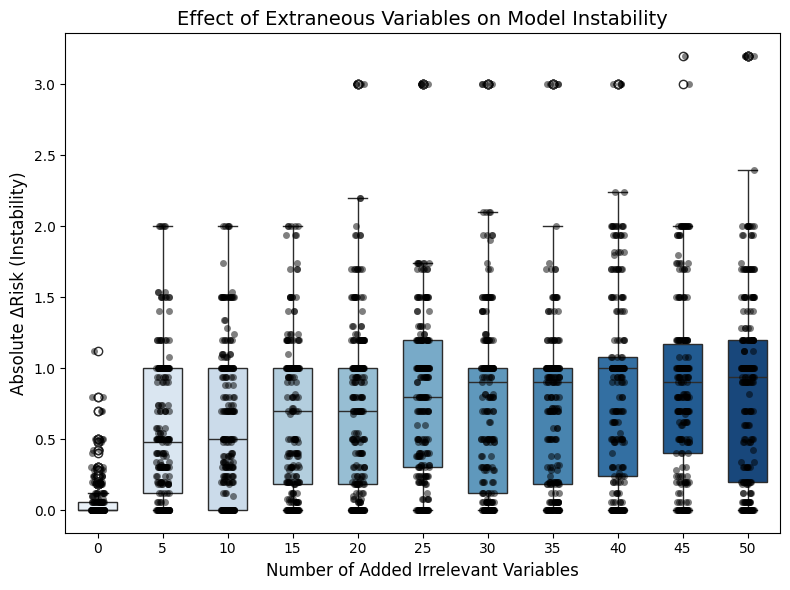

In [7]:

plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df,
    x="Added_Vars",
    y="Abs_Delta_Risk",
    palette="Blues",
    width=0.6
)

sns.stripplot(
    data=df,
    x="Added_Vars",
    y="Abs_Delta_Risk",
    color="black",
    alpha=0.5,
    jitter=True
)

plt.title("Effect of Extraneous Variables on Model Instability", fontsize=14)
plt.xlabel("Number of Added Irrelevant Variables", fontsize=12)
plt.ylabel("Absolute ΔRisk (Instability)", fontsize=12)
plt.tight_layout()
plt.show()


   Added_Vars  SD_Abs_Delta_Risk
0           0           0.154796
1          50           0.694590


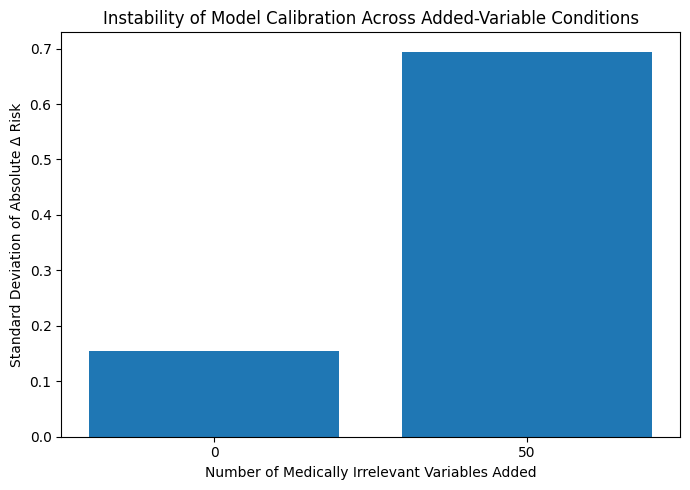

In [8]:
conditions_of_interest = [0, 6, 50]
df_subset = df[df["Added_Vars"].isin(conditions_of_interest)]

# Compute SD of Abs_Delta_Risk for each condition
sd_table = df_subset.groupby("Added_Vars")["Abs_Delta_Risk"].std().reset_index()
sd_table.columns = ["Added_Vars", "SD_Abs_Delta_Risk"]

print(sd_table)

# --- Plot ---
plt.figure(figsize=(7,5))
plt.bar(sd_table["Added_Vars"].astype(str), sd_table["SD_Abs_Delta_Risk"])
plt.xlabel("Number of Medically Irrelevant Variables Added")
plt.ylabel("Standard Deviation of Absolute Δ Risk")
plt.title("Instability of Model Calibration Across Added-Variable Conditions")
plt.tight_layout()
plt.show()

Prompt Variations


--- Neutral ---
  Intercept:   0.391
  Added_Vars:  0.0114  (p = 0.0000)
  Cumulative drift at +50 vars: 0.572

--- Logical ---
  Intercept:   0.727
  Added_Vars:  -0.0049  (p = 0.0396)
  Cumulative drift at +50 vars: -0.245

--- Human Impact ---
  Intercept:   0.691
  Added_Vars:  0.0045  (p = 0.0090)
  Cumulative drift at +50 vars: 0.226

--- Clinical Judgement ---
  Intercept:   0.232
  Added_Vars:  0.0040  (p = 0.0000)
  Cumulative drift at +50 vars: 0.199


/var/folders/z_/5vjxj12n6l1_lx8vl9hfs5h80000gn/T/ipykernel_19822/2755924323.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/z_/5vjxj12n6l1_lx8vl9hfs5h80000gn/T/ipykernel_19822/2755924323.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/z_/5vjxj12n6l1_lx8vl9hfs5h80000gn/T/ipykernel_19822/2755924323.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/z_/5vjxj12n6l1_lx8vl9hfs5h80000gn/T/ipykernel_19822/2755924323.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

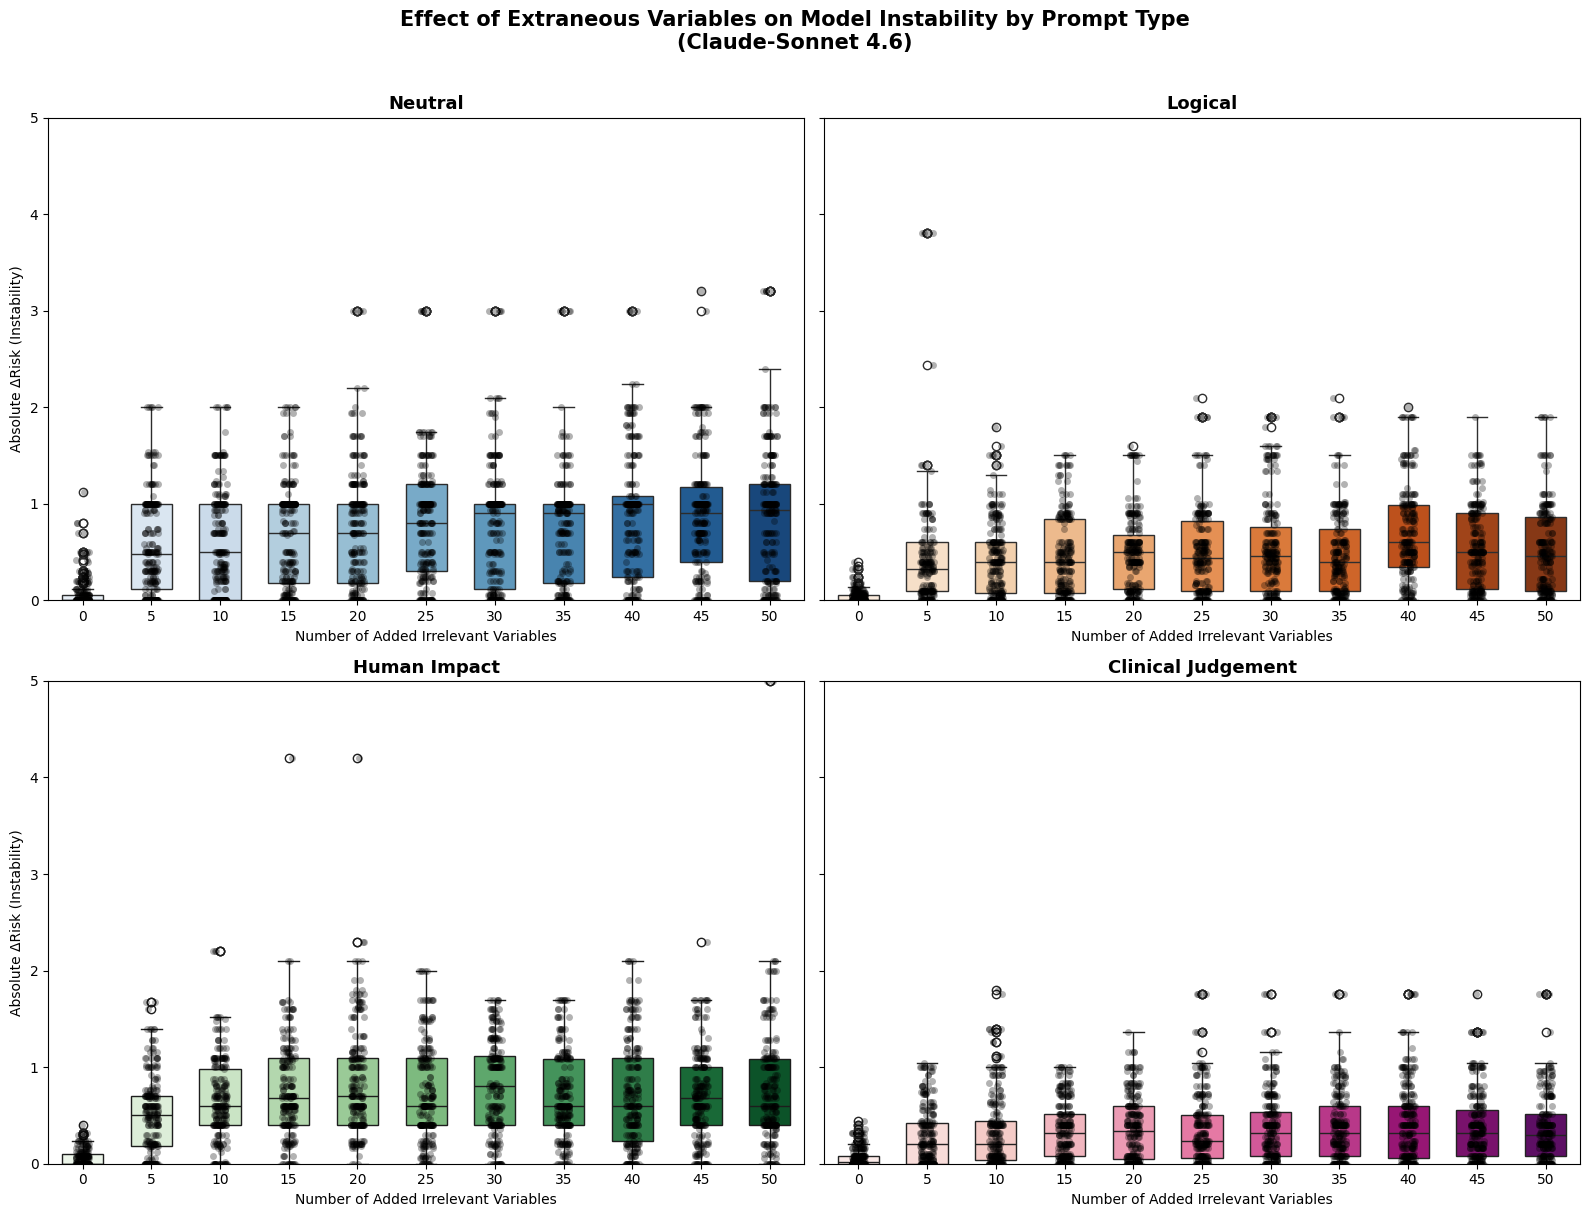

Saved: instability_by_prompt_claude.png


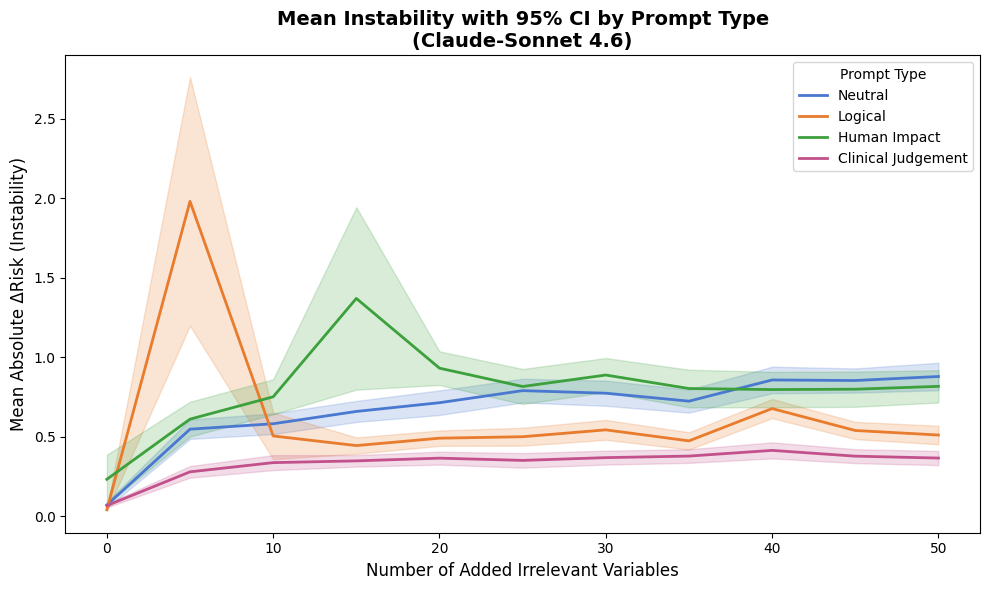

Saved: ci_instability_by_prompt_claude.png


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# -------------------------
# Load all four prompt CSVs
# -------------------------
prompt_files = {
    "Neutral":             "scores_anthropic_claude-sonnet-4.6_neutral.csv",
    "Logical":             "scores_anthropic_claude-sonnet-4.6_logical.csv",
    "Human Impact":        "scores_anthropic_claude-sonnet-4.6_human_impact.csv",
    "Clinical Judgement":  "scores_anthropic_claude-sonnet-4.6_clinical_judgement.csv",
}

# -------------------------
# Helper: prep dataframe
# -------------------------
def prepare_df(path):
    df = pd.read_csv(path)
    baseline_means = (
        df[df["Condition"] == "baseline"]
        .groupby("Patient_ID")["Risk_Score"]
        .mean()
        .rename("Baseline_Risk")
    )
    df = df.merge(baseline_means, on="Patient_ID", how="left")
    df["Abs_Delta_Risk"] = (df["Risk_Score"] - df["Baseline_Risk"]).abs()
    df = df.dropna(subset=["Abs_Delta_Risk", "Added_Vars"]).reset_index(drop=True)
    return df

# -------------------------
# Run mixed LM for each prompt
# -------------------------
print("=" * 60)
for prompt_name, path in prompt_files.items():
    df = prepare_df(path)
    model = smf.mixedlm("Abs_Delta_Risk ~ Added_Vars", df, groups=df["Patient_ID"])
    result = model.fit()
    coef = result.params["Added_Vars"]
    pval = result.pvalues["Added_Vars"]
    intercept = result.params["Intercept"]
    print(f"\n--- {prompt_name} ---")
    print(f"  Intercept:   {intercept:.3f}")
    print(f"  Added_Vars:  {coef:.4f}  (p = {pval:.4f})")
    print(f"  Cumulative drift at +50 vars: {coef * 50:.3f}")
print("=" * 60)

# -------------------------
# 4-panel box + strip plot
# -------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
axes = axes.flatten()

palettes = ["Blues", "Oranges", "Greens", "RdPu"]

for ax, (prompt_name, path), palette in zip(axes, prompt_files.items(), palettes):
    df = prepare_df(path)

    sns.boxplot(
        data=df,
        x="Added_Vars",
        y="Abs_Delta_Risk",
        palette=palette,
        width=0.6,
        ax=ax
    )
    sns.stripplot(
        data=df,
        x="Added_Vars",
        y="Abs_Delta_Risk",
        color="black",
        alpha=0.3,
        jitter=True,
        ax=ax
    )

    ax.set_ylim(0, 5) 
    ax.set_title(f"{prompt_name}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Number of Added Irrelevant Variables", fontsize=10)
    ax.set_ylabel("Absolute ΔRisk (Instability)", fontsize=10)

fig.suptitle(
    "Effect of Extraneous Variables on Model Instability by Prompt Type\n(Claude-Sonnet 4.6)",
    fontsize=15,
    fontweight="bold",
    y=1.01
)
plt.tight_layout()
plt.savefig("instability_by_prompt_claude.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: instability_by_prompt_claude.png")

# -------------------------
# 95% CI plot — mean Abs_Delta_Risk by Added_Vars per prompt
# -------------------------
import numpy as np
from scipy import stats

ci_colors = {
    "Neutral":            "#4878CF",
    "Logical":            "#E87B2C",
    "Human Impact":       "#3CA03C",
    "Clinical Judgement": "#C2508A",
}

fig2, ax = plt.subplots(figsize=(10, 6))

for prompt_name, path in prompt_files.items():
    df = prepare_df(path)
    grouped = df.groupby("Added_Vars")["Abs_Delta_Risk"]

    means = grouped.mean()
    sems  = grouped.sem()
    ci    = sems * stats.t.ppf(0.975, df=grouped.count() - 1)

    x = means.index
    ax.plot(x, means, label=prompt_name, color=ci_colors[prompt_name], linewidth=2)
    ax.fill_between(x, means - ci, means + ci, alpha=0.2, color=ci_colors[prompt_name])

ax.set_title(
    "Mean Instability with 95% CI by Prompt Type\n(Claude-Sonnet 4.6)",
    fontsize=14, fontweight="bold"
)
ax.set_xlabel("Number of Added Irrelevant Variables", fontsize=12)
ax.set_ylabel("Mean Absolute ΔRisk (Instability)", fontsize=12)
ax.legend(title="Prompt Type", fontsize=10)
plt.tight_layout()
plt.savefig("ci_instability_by_prompt_claude.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ci_instability_by_prompt_claude.png")

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import numpy as np
from scipy import stats

# =========================================================
# CHANGE 1: swap in your model's CSV filenames and labels
# =========================================================

# --- CLAUDE ---
prompt_files_claude = {
    "Neutral":            "scores_anthropic_claude-sonnet-4.6_neutral.csv",
    "Logical":            "scores_anthropic_claude-sonnet-4.6_logical.csv",
    "Human Impact":       "scores_anthropic_claude-sonnet-4.6_human_impact.csv",
    "Clinical Judgement": "scores_anthropic_claude-sonnet-4.6_clinical_judgement.csv",
}
MODEL_LABEL_CLAUDE  = "Claude Sonnet 4.6"   # CHANGE 2a: display label for plots/prints
MODEL_PREFIX_CLAUDE = "claude"               # CHANGE 2b: used in saved filenames


# =========================================================
# Helper: prep dataframe — no changes needed here
# =========================================================
def prepare_df(path, prompt_name=None):
    df = pd.read_csv(path)
    baseline_means = (
        df[df["Condition"] == "baseline"]
        .groupby("Patient_ID")["Risk_Score"]
        .mean()
        .rename("Baseline_Risk")
    )
    df = df.merge(baseline_means, on="Patient_ID", how="left")
    df["Abs_Delta_Risk"] = (df["Risk_Score"] - df["Baseline_Risk"]).abs()
    df = df.dropna(subset=["Abs_Delta_Risk", "Added_Vars"]).reset_index(drop=True)
    if prompt_name:
        df["Prompt"] = prompt_name
    return df


# =========================================================
# Core analysis function — runs both models for any model
# =========================================================
def run_analysis(prompt_files, model_label, model_prefix):

    print("\n" + "=" * 60)
    print(f"MODEL: {model_label}")
    print("=" * 60)

    # --- Per-prompt mixed LM ---
    print("\nPER-PROMPT MIXED EFFECTS MODELS")
    print("-" * 40)
    for prompt_name, path in prompt_files.items():
        df = prepare_df(path)
        model  = smf.mixedlm("Abs_Delta_Risk ~ Added_Vars", df, groups=df["Patient_ID"])
        result = model.fit(reml=True)
        coef      = result.params["Added_Vars"]
        pval      = result.pvalues["Added_Vars"]
        intercept = result.params["Intercept"]
        print(f"\n  --- {prompt_name} ---")
        print(f"    Intercept:              {intercept:.3f}")
        print(f"    Added_Vars coefficient: {coef:.4f}  (p = {pval:.4f})")
        print(f"    Cumulative drift +50:   {coef * 50:.3f}")

    # --- Combined model ---
    df_all = pd.concat([
        prepare_df(path, prompt_name=name)
        for name, path in prompt_files.items()
    ], ignore_index=True)

    df_all["Prompt"] = pd.Categorical(
        df_all["Prompt"],
        categories=["Neutral", "Logical", "Human Impact", "Clinical Judgement"]
    )

    print("\nCOMBINED MODEL 1 — main effects")
    print("-" * 40)
    m1 = smf.mixedlm(
        "Abs_Delta_Risk ~ Added_Vars + C(Prompt, Treatment('Neutral'))",
        df_all, groups=df_all["Patient_ID"]
    )
    r1 = m1.fit(reml=True)
    print(r1.summary())

    print("\nCOMBINED MODEL 2 — interaction")
    print("-" * 40)
    m2 = smf.mixedlm(
        "Abs_Delta_Risk ~ Added_Vars * C(Prompt, Treatment('Neutral'))",
        df_all, groups=df_all["Patient_ID"]
    )
    r2 = m2.fit(reml=True)
    print(r2.summary())

    # --- Key coefficients ---
    print("\nKEY COEFFICIENTS — MODEL 2")
    print("=" * 60)
    for k in ["Intercept", "Added_Vars"]:
        b = r2.params[k]; p = r2.pvalues[k]
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        print(f"  {k:<45} β = {b:.4f}  p = {p:.4f}  {sig}")

    for label in ["Logical", "Human Impact", "Clinical Judgement"]:
        for k in [
            f"C(Prompt, Treatment('Neutral'))[T.{label}]",
            f"Added_Vars:C(Prompt, Treatment('Neutral'))[T.{label}]"
        ]:
            if k in r2.params:
                b = r2.params[k]; p = r2.pvalues[k]
                sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
                short = k.replace("C(Prompt, Treatment('Neutral'))", "Prompt")
                print(f"  {short:<45} β = {b:.4f}  p = {p:.4f}  {sig}")

    print("=" * 60)
    print(f"  Results saved for {model_label}")

    return r1, r2, df_all


# =========================================================
# RUN — comment out whichever model you don't need yet
# =========================================================
r1_claude, r2_claude, df_claude = run_analysis(
    prompt_files_claude, MODEL_LABEL_CLAUDE, MODEL_PREFIX_CLAUDE
)



MODEL: Claude Sonnet 4.6

PER-PROMPT MIXED EFFECTS MODELS
----------------------------------------

  --- Neutral ---
    Intercept:              0.391
    Added_Vars coefficient: 0.0114  (p = 0.0000)
    Cumulative drift +50:   0.572

  --- Logical ---
    Intercept:              0.727
    Added_Vars coefficient: -0.0049  (p = 0.0396)
    Cumulative drift +50:   -0.245

  --- Human Impact ---
    Intercept:              0.691
    Added_Vars coefficient: 0.0045  (p = 0.0090)
    Cumulative drift +50:   0.226

  --- Clinical Judgement ---
    Intercept:              0.232
    Added_Vars coefficient: 0.0040  (p = 0.0000)
    Cumulative drift +50:   0.199

COMBINED MODEL 1 — main effects
----------------------------------------
                             Mixed Linear Model Regression Results
Model:                        MixedLM             Dependent Variable:             Abs_Delta_Risk
No. Observations:             10849               Method:                         REML          
No.